# Homework №4

**Cluster the data based on interval or ratio scale variables:**
* Select not less than 5 variables, check that the selected data are applicable for cluster analysis.
* Select an appropriate clustering algorithm and explain your selection.
* Define the number of clusters and explain your decision.
* Describe the clusters using descriptive statistics. Please note, that it’s not enough just to create a table with the descriptive statistics. The important aspect of the analysis is the interpretation of the obtained results. You should provide the textual description of each cluster so as it will be clear what are the specific features of each cluster.
* Try to give names to the obtained clusters and explain your selection of names.
* Do a post-hoc analysis to approve the validity of your results. *italicized text*

In [ ]:
!pip install yellowbrick

In [ ]:
import pandas as pd
%matplotlib inline
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data Analysis/laptops.csv')

In [ ]:
df.head()

,index,brand,Model,Price,Rating,processor_brand,processor_tier,num_cores,num_threads,ram_memory,...,secondary_storage_type,secondary_storage_capacity,gpu_brand,gpu_type,is_touch_screen,display_size,resolution_width,resolution_height,OS,year_of_warranty
0,1,tecno,Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...,23990,63,intel,core i3,2,4,8,...,No secondary storage,0,intel,integrated,False,15.6,1920,1080,windows,1
1,2,tecno,Tecno Megabook T1 Laptop (11th Gen Core i7/ 16...,35990,67,intel,core i7,4,8,16,...,No secondary storage,0,intel,integrated,False,15.6,1920,1080,windows,1
2,3,hp,HP Victus 15-fb0157AX Gaming Laptop (AMD Ryzen...,51100,73,amd,ryzen 5,6,12,8,...,No secondary storage,0,amd,dedicated,False,15.6,1920,1080,windows,1
3,4,acer,Acer Extensa EX214-53 Laptop (12th Gen Core i5...,39990,62,intel,core i5,12,16,8,...,No secondary storage,0,intel,integrated,False,14.0,1920,1080,windows,1
4,5,lenovo,Lenovo V15 82KDA01BIH Laptop (AMD Ryzen 3 5300...,28580,62,amd,ryzen 3,4,8,8,...,No secondary storage,0,amd,integrated,False,15.6,1920,1080,windows,1


**Cluster the data based on interval or ratio scale variables:**
* Select not less than 5 variables, check that the selected data are applicable for cluster analysis.
* Select an appropriate clustering algorithm and explain your selection.
* Define the number of clusters and explain your decision.
* Describe the clusters using descriptive statistics. Please note, that it’s not enough just to create a table with the descriptive statistics. The important aspect of the analysis is the interpretation of the obtained results. You should provide the textual description of each cluster so as it will be clear what are the specific features of each cluster.
* Try to give names to the obtained clusters and explain your selection of names.
* Do a post-hoc analysis to approve the validity of your results.

## Selected pairs of variables



In [ ]:
quantitative_columns = ['Price', 'Rating', 'num_cores', 'num_threads', 'ram_memory',
                        'primary_storage_capacity', 'secondary_storage_capacity',
                        'display_size', 'resolution_width', 'resolution_height']

correlation_matrix_quantitative = df[quantitative_columns].corr()

correlation_matrix_quantitative

,Price,Rating,num_cores,num_threads,ram_memory,primary_storage_capacity,secondary_storage_capacity,display_size,resolution_width,resolution_height
Price,1.000000,0.661422,0.724455,0.719529,0.633124,0.636343,-0.013604,0.211435,0.640306,0.622278
Rating,0.661422,1.000000,0.596742,0.773804,0.656670,0.597511,0.054120,0.351006,0.442884,0.397276
num_cores,0.724455,0.596742,1.000000,0.907461,0.571827,0.504004,-0.058476,0.192633,0.483649,0.465953
num_threads,0.719529,0.773804,0.907461,1.000000,0.635319,0.569151,-0.022038,0.312085,0.474487,0.447842
ram_memory,0.633124,0.656670,0.571827,0.635319,1.000000,0.526822,0.010703,0.143869,0.436563,0.427901
primary_storage_capacity,0.636343,0.597511,0.504004,0.569151,0.526822,1.000000,0.171913,0.215639,0.414564,0.376179
secondary_storage_capacity,-0.013604,0.054120,-0.058476,-0.022038,0.010703,0.171913,1.000000,0.032004,-0.047017,-0.059023
display_size,0.211435,0.351006,0.192633,0.312085,0.143869,0.215639,0.032004,1.000000,0.070505,-0.028706
resolution_width,0.640306,0.442884,0.483649,0.474487,0.436563,0.414564,-0.047017,0.070505,1.000000,0.814224
resolution_height,0.622278,0.397276,0.465953,0.447842,0.427901,0.376179,-0.059023,-0.028706,0.814224,1.000000


**As a result of the correlation analysis, the following pairs were selected for cluster analysis:**

* Price and display_size
* Rating and resolution_height
* display_size and ram_memory

<font color = 'red'>In this task you had to pick >=5 variables and compute cluster analysis including them all simultaneously.</font>

## Price and display_size cluster analysis

In [ ]:
df['z_Price'] = (df['Price'] - df['Price'].mean())/df['Price'].std()
df['z_display_size'] = (df['display_size'] - df['display_size'].mean())/df['display_size'].std()
df

,index,brand,Model,Price,Rating,processor_brand,processor_tier,num_cores,num_threads,ram_memory,...,gpu_brand,gpu_type,is_touch_screen,display_size,resolution_width,resolution_height,OS,year_of_warranty,z_Price,z_display_size
0,1,tecno,Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...,23990,63,intel,core i3,2,4,8,...,intel,integrated,False,15.6,1920,1080,windows,1,-0.928406,0.457056
1,2,tecno,Tecno Megabook T1 Laptop (11th Gen Core i7/ 16...,35990,67,intel,core i7,4,8,16,...,intel,integrated,False,15.6,1920,1080,windows,1,-0.719292,0.457056
2,3,hp,HP Victus 15-fb0157AX Gaming Laptop (AMD Ryzen...,51100,73,amd,ryzen 5,6,12,8,...,amd,dedicated,False,15.6,1920,1080,windows,1,-0.455982,0.457056
3,4,acer,Acer Extensa EX214-53 Laptop (12th Gen Core i5...,39990,62,intel,core i5,12,16,8,...,intel,integrated,False,14.0,1920,1080,windows,1,-0.649587,-1.248540
4,5,lenovo,Lenovo V15 82KDA01BIH Laptop (AMD Ryzen 3 5300...,28580,62,amd,ryzen 3,4,8,8,...,amd,integrated,False,15.6,1920,1080,windows,1,-0.848420,0.457056
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
986,998,asus,Asus Vivobook Pro 15 M6500QC-HN542WS Laptop (R...,65990,68,amd,ryzen 5,6,12,16,...,nvidia,dedicated,False,15.6,1920,1080,windows,1,-0.196506,0.457056
987,999,msi,MSI Thin GF63 12VE-070IN Gaming Laptop (12th G...,91990,73,intel,core i7,10,16,16,...,nvidia,dedicated,False,15.6,1920,1080,windows,2,0.256574,0.457056
988,1000,asus,Asus Vivobook Go 15 2023 E1504FA-NJ522WS Lapto...,44990,59,amd,ryzen 5,4,8,8,...,amd,integrated,False,15.6,1920,1080,windows,1,-0.562456,0.457056
989,1001,asus,Asus Zenbook 14 2023 UM3402YA-KP541WS Laptop (...,67990,68,amd,ryzen 5,6,12,16,...,amd,integrated,False,14.0,2560,1600,windows,1,-0.161654,-1.248540


In [ ]:
X = df[['z_Price', 'z_display_size']]
X

,z_Price,z_display_size
0,-0.928406,0.457056
1,-0.719292,0.457056
2,-0.455982,0.457056
3,-0.649587,-1.248540
4,-0.848420,0.457056
...,...,...
986,-0.196506,0.457056
987,0.256574,0.457056
988,-0.562456,0.457056
989,-0.161654,-1.248540


In [ ]:
for k in range (2, 15):
    labels = KMeans(n_clusters=k).fit_predict(X)
    print('Number of clusters: {}, index {}'.format(k, calinski_harabasz_score(X, labels)))

Number of clusters: 2, index 503.2533070612151
Number of clusters: 3, index 1202.232163605371
Number of clusters: 4, index 1182.0262552307183
Number of clusters: 5, index 1214.3564978878399
Number of clusters: 6, index 1107.7630243766437
Number of clusters: 7, index 1141.7269053006455
Number of clusters: 8, index 1250.103617617625
Number of clusters: 9, index 1308.4043034190001
Number of clusters: 10, index 1497.3833069659947
Number of clusters: 11, index 1410.954940732493
Number of clusters: 12, index 1417.8740141936814
Number of clusters: 13, index 1486.7785544510132
Number of clusters: 14, index 1597.790852279883


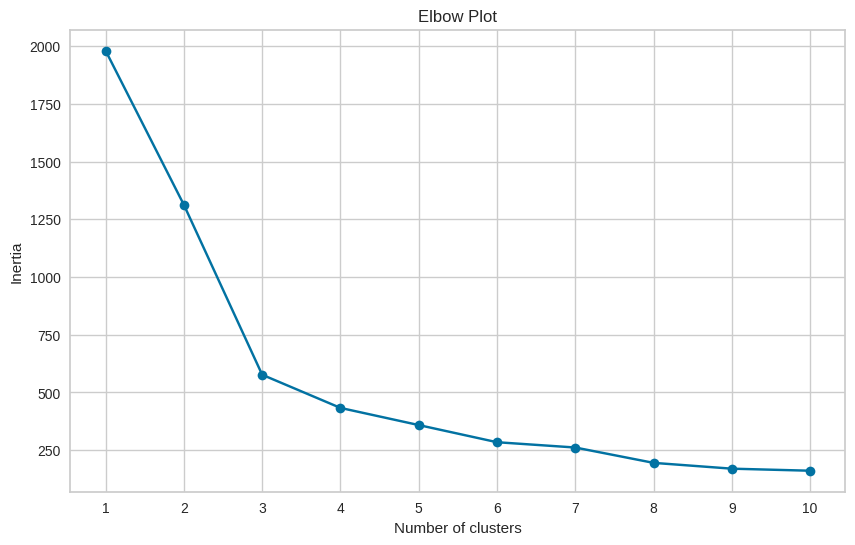

In [ ]:
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Plot')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.show()

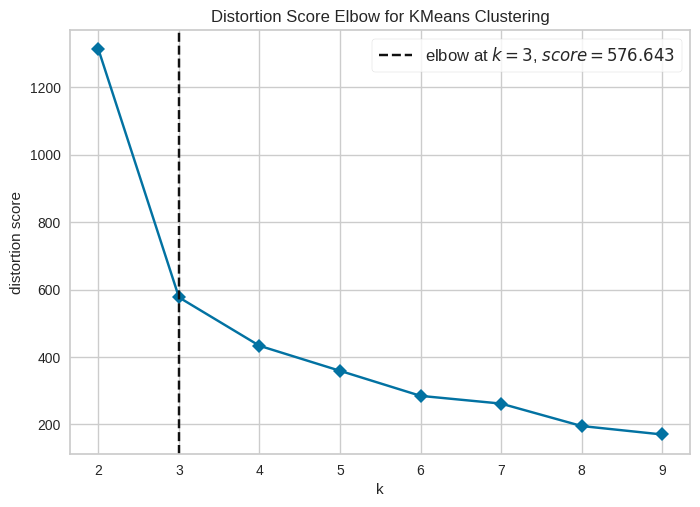

In [ ]:
from yellowbrick.cluster import KElbowVisualizer

model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2,10), timings=False)

visualizer.fit(X)
visualizer.show()
plt.show()

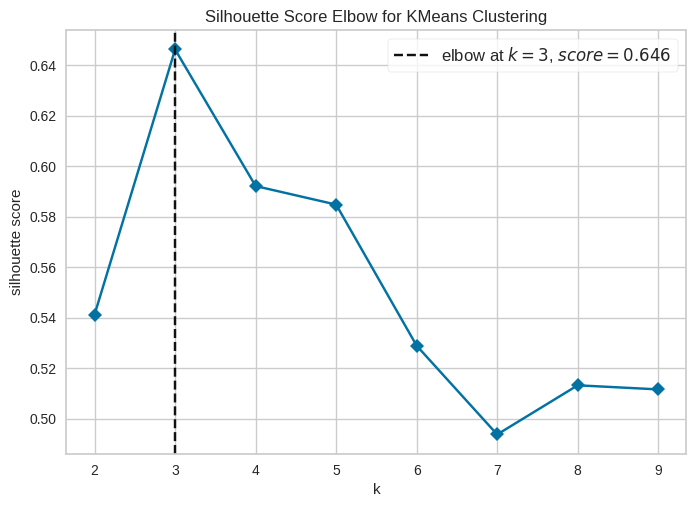

In [ ]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2,10), metric='silhouette', timings=False)

visualizer.fit(X)
visualizer.show()
plt.show()

In [ ]:
kmeans_model = KMeans(n_clusters=3).fit_predict(X)

In [ ]:
df['Clusters'] = kmeans_model
df.head()

,index,brand,Model,Price,Rating,processor_brand,processor_tier,num_cores,num_threads,ram_memory,...,gpu_type,is_touch_screen,display_size,resolution_width,resolution_height,OS,year_of_warranty,z_Price,z_display_size,Clusters
0,1,tecno,Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...,23990,63,intel,core i3,2,4,8,...,integrated,False,15.6,1920,1080,windows,1,-0.928406,0.457056,1
1,2,tecno,Tecno Megabook T1 Laptop (11th Gen Core i7/ 16...,35990,67,intel,core i7,4,8,16,...,integrated,False,15.6,1920,1080,windows,1,-0.719292,0.457056,1
2,3,hp,HP Victus 15-fb0157AX Gaming Laptop (AMD Ryzen...,51100,73,amd,ryzen 5,6,12,8,...,dedicated,False,15.6,1920,1080,windows,1,-0.455982,0.457056,1
3,4,acer,Acer Extensa EX214-53 Laptop (12th Gen Core i5...,39990,62,intel,core i5,12,16,8,...,integrated,False,14.0,1920,1080,windows,1,-0.649587,-1.248540,0
4,5,lenovo,Lenovo V15 82KDA01BIH Laptop (AMD Ryzen 3 5300...,28580,62,amd,ryzen 3,4,8,8,...,integrated,False,15.6,1920,1080,windows,1,-0.848420,0.457056,1


In [ ]:
df['Clusters'].value_counts()

,count
Clusters,
1,623
0,286
2,82


In [ ]:
df.groupby('Clusters')[['z_Price', 'z_display_size']].mean(numeric_only=True)

,z_Price,z_display_size
Clusters,,
0,-0.773595,-0.960922
1,-0.235967,0.086762
2,2.666875,0.179896
3,1.471051,0.231111
4,1.101994,-0.696840


In [ ]:
df.groupby('Clusters')[['z_Price', 'z_display_size']].describe()

z_Price                                                              \
           count      mean       std       min       25%       50%       75%   
Clusters                                                                       
0          286.0 -0.204239  0.609692 -1.175684 -0.656810 -0.275708  0.147661   
1          623.0 -0.247054  0.472533 -1.032963 -0.597309 -0.346372 -0.022245   
2           82.0  2.589349  1.339941  1.169985  1.522626  2.139474  3.195104   

                   z_display_size                                          \
               max          count      mean       std       min       25%   
Clusters                                                                    
0         2.311121          286.0 -1.410303  0.522055 -5.405929 -1.248540   
1         1.180162          623.0  0.546203  0.256573 -0.182543  0.457056   
2         6.573566           82.0  0.769055  0.917431 -1.994738  0.883455   

                                        
               50%       75%       max  
Clusters                                
0        -1.248540 -1.248540 -0.715541  
1         0.457056  0.457056  2.269251  
2         0.883455  0.990054  3.015449

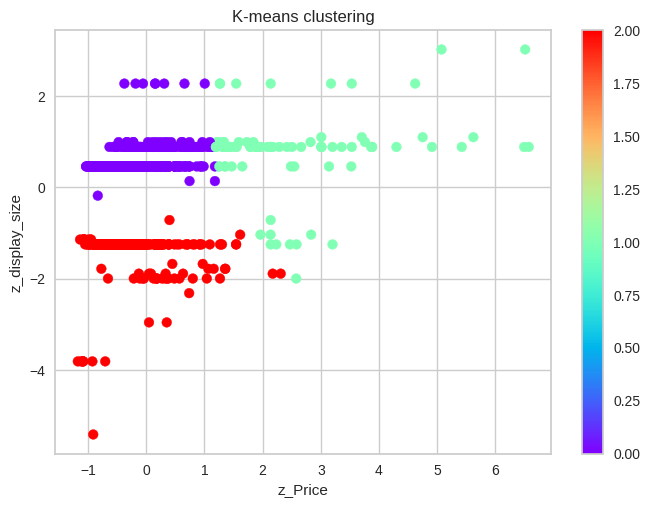

In [ ]:
k_means = KMeans(n_clusters = 3)
k_means = k_means.fit(X)
clusters = k_means.predict(X)
plt.scatter(df['z_Price'], df['z_display_size'], c = clusters, cmap = 'rainbow')
plt.xlabel('z_Price')
plt.ylabel('z_display_size')
plt.title('K-means clustering')
plt.colorbar()
plt.show()

### Cluster analysis

**Cluster 0:** Budget compact laptops

These are devices with low prices and small screens.

**Cluster 1:** Mid-range notebook

Laptops from this cluster are moderately priced and have a standard screen size.

**Cluster 2:** Premium laptops

Laptops in this cluster have the highest prices and a wide variation in screen size.

### Result validation

In [ ]:
import pandas as pd
from scipy import stats

f_val_price, p_val_price = stats.f_oneway(
    df[df['Clusters'] == 0]['z_Price'],
    df[df['Clusters'] == 1]['z_Price'],
    df[df['Clusters'] == 2]['z_Price'],
)

f_val_display_size, p_val_display_size = stats.f_oneway(
    df[df['Clusters'] == 0]['z_display_size'],
    df[df['Clusters'] == 1]['z_display_size'],
    df[df['Clusters'] == 2]['z_display_size'],
)

print(f"ANOVA Results for z_Price: F-value = {f_val_price}, P-value = {p_val_price}")
print(f"ANOVA Results for z_display_size: F-value = {f_val_display_size}, P-value = {p_val_display_size}")

ANOVA Results for z_Price: F-value = 159.9679632947157, P-value = 1.3970544807159585e-59
ANOVA Results for z_display_size: F-value = 32.71052843720498, P-value = 2.0924185257733014e-14


Both tests show that the clusters differ significantly on both variables, z_Price and z_display_size. This means that the results of the cluster analysis are valid and the clusters do reflect differences between laptops in terms of price and screen size.

## Rating and resolution_height

In [ ]:
df['z_Rating'] = (df['Rating'] - df['Rating'].mean())/df['Rating'].std()
df['z_resolution_height'] = (df['resolution_height'] - df['resolution_height'].mean())/df['resolution_height'].std()
df

,index,brand,Model,Price,Rating,processor_brand,processor_tier,num_cores,num_threads,ram_memory,...,resolution_height,OS,year_of_warranty,z_Price,z_display_size,Clusters,z_ram_memory,z_primary_storage_capacity,z_Rating,z_resolution_height
0,1,tecno,Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...,23990,63,intel,core i3,2,4,8,...,1080,windows,1,-0.928406,0.457056,2,-0.902747,-0.370656,-0.091396,-0.383604
1,2,tecno,Tecno Megabook T1 Laptop (11th Gen Core i7/ 16...,35990,67,intel,core i7,4,8,16,...,1080,windows,1,-0.719292,0.457056,0,0.528076,1.547466,0.301123,-0.383604
2,3,hp,HP Victus 15-fb0157AX Gaming Laptop (AMD Ryzen...,51100,73,amd,ryzen 5,6,12,8,...,1080,windows,1,-0.455982,0.457056,2,-0.902747,-0.370656,0.889902,-0.383604
3,4,acer,Acer Extensa EX214-53 Laptop (12th Gen Core i5...,39990,62,intel,core i5,12,16,8,...,1080,windows,1,-0.649587,-1.248540,3,-0.902747,-0.370656,-0.189526,-0.383604
4,5,lenovo,Lenovo V15 82KDA01BIH Laptop (AMD Ryzen 3 5300...,28580,62,amd,ryzen 3,4,8,8,...,1080,windows,1,-0.848420,0.457056,2,-0.902747,-0.370656,-0.189526,-0.383604
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
986,998,asus,Asus Vivobook Pro 15 M6500QC-HN542WS Laptop (R...,65990,68,amd,ryzen 5,6,12,16,...,1080,windows,1,-0.196506,0.457056,0,0.528076,-0.370656,0.399253,-0.383604
987,999,msi,MSI Thin GF63 12VE-070IN Gaming Laptop (12th G...,91990,73,intel,core i7,10,16,16,...,1080,windows,2,0.256574,0.457056,0,0.528076,-0.370656,0.889902,-0.383604
988,1000,asus,Asus Vivobook Go 15 2023 E1504FA-NJ522WS Lapto...,44990,59,amd,ryzen 5,4,8,8,...,1080,windows,1,-0.562456,0.457056,2,-0.902747,-0.370656,-0.483916,-0.383604
989,1001,asus,Asus Zenbook 14 2023 UM3402YA-KP541WS Laptop (...,67990,68,amd,ryzen 5,6,12,16,...,1600,windows,1,-0.161654,-1.248540,1,0.528076,-0.370656,0.399253,1.586958


In [ ]:
X = df[['Rating', 'resolution_height']]
X

,Rating,resolution_height
0,63,1080
1,67,1080
2,73,1080
3,62,1080
4,62,1080
...,...,...
986,68,1080
987,73,1080
988,59,1080
989,68,1600


In [ ]:
for k in range (2, 15):
    labels = KMeans(n_clusters=k).fit_predict(X)
    print('Number of clusters: {}, index {}'.format(k, calinski_harabasz_score(X, labels)))

Number of clusters: 2, index 3811.9356805964803
Number of clusters: 3, index 3395.581776180964
Number of clusters: 4, index 5313.062210476946
Number of clusters: 5, index 6624.541385759846
Number of clusters: 6, index 13558.864727591106
Number of clusters: 7, index 18429.8555469107
Number of clusters: 8, index 31753.446329423798
Number of clusters: 9, index 49297.37336336414
Number of clusters: 10, index 50586.74364008383
Number of clusters: 11, index 50257.09308588218
Number of clusters: 12, index 50036.13209800525
Number of clusters: 13, index 52127.48730004086
Number of clusters: 14, index 63509.6979048131


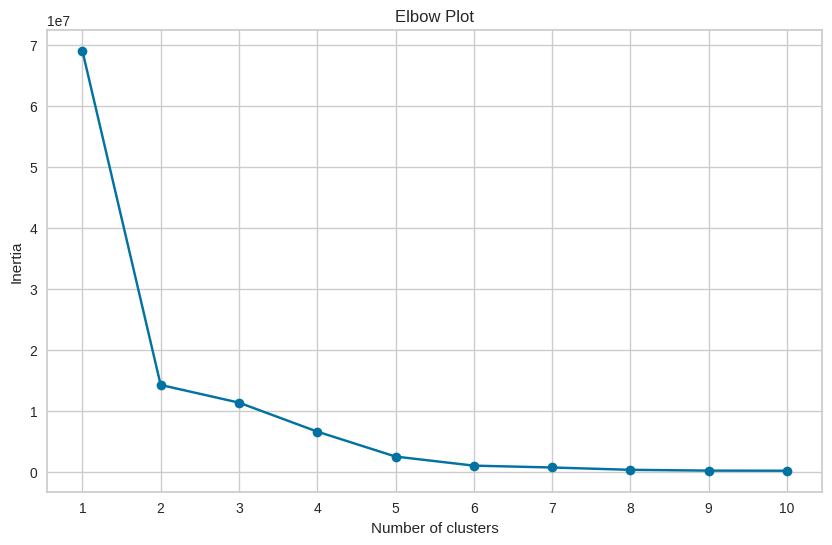

In [ ]:
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Plot')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.show()

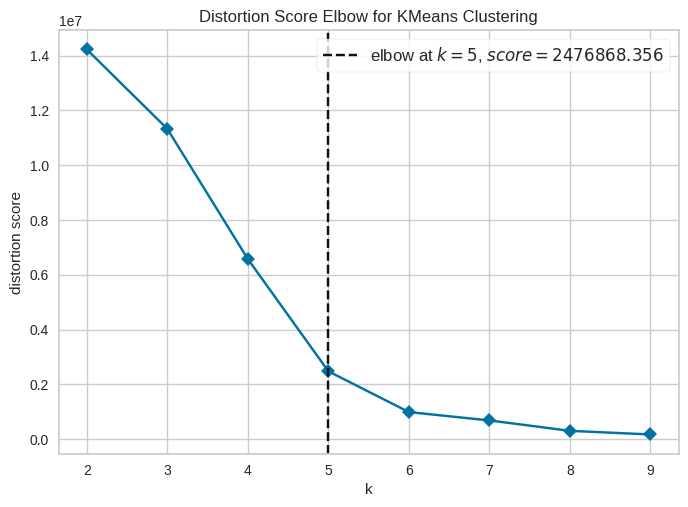

In [ ]:
from yellowbrick.cluster import KElbowVisualizer

model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2,10), timings=False)

visualizer.fit(X)
visualizer.show()
plt.show()

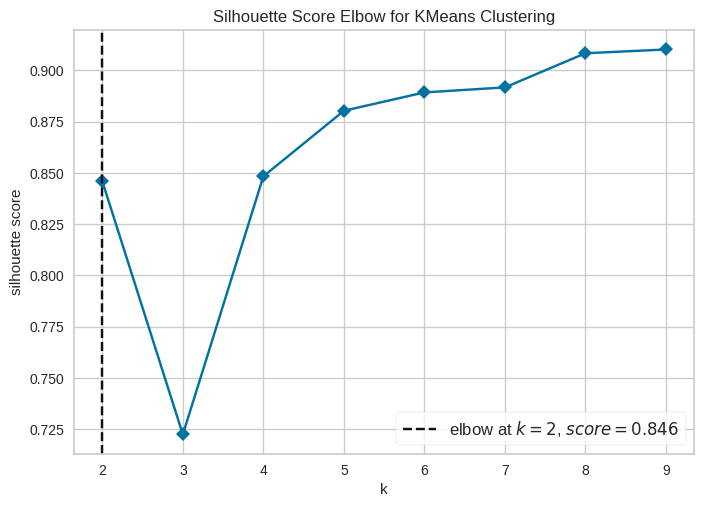

In [ ]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2,10), metric='silhouette', timings=False)

visualizer.fit(X)
visualizer.show()
plt.show()

In [ ]:
kmeans_model = KMeans(n_clusters=5).fit_predict(X)

In [ ]:
df['Clusters'] = kmeans_model
df.head()

,index,brand,Model,Price,Rating,processor_brand,processor_tier,num_cores,num_threads,ram_memory,...,resolution_height,OS,year_of_warranty,z_Price,z_display_size,Clusters,z_ram_memory,z_primary_storage_capacity,z_Rating,z_resolution_height
0,1,tecno,Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...,23990,63,intel,core i3,2,4,8,...,1080,windows,1,-0.928406,0.457056,1,-0.902747,-0.370656,-0.091396,-0.383604
1,2,tecno,Tecno Megabook T1 Laptop (11th Gen Core i7/ 16...,35990,67,intel,core i7,4,8,16,...,1080,windows,1,-0.719292,0.457056,1,0.528076,1.547466,0.301123,-0.383604
2,3,hp,HP Victus 15-fb0157AX Gaming Laptop (AMD Ryzen...,51100,73,amd,ryzen 5,6,12,8,...,1080,windows,1,-0.455982,0.457056,1,-0.902747,-0.370656,0.889902,-0.383604
3,4,acer,Acer Extensa EX214-53 Laptop (12th Gen Core i5...,39990,62,intel,core i5,12,16,8,...,1080,windows,1,-0.649587,-1.248540,1,-0.902747,-0.370656,-0.189526,-0.383604
4,5,lenovo,Lenovo V15 82KDA01BIH Laptop (AMD Ryzen 3 5300...,28580,62,amd,ryzen 3,4,8,8,...,1080,windows,1,-0.848420,0.457056,1,-0.902747,-0.370656,-0.189526,-0.383604


In [ ]:
df['Clusters'].value_counts()

,count
Clusters,
1,779
3,92
4,57
0,53
2,10


In [ ]:
df.groupby('Clusters')[['Rating', 'resolution_height']].mean(numeric_only=True)

,Rating,resolution_height
Clusters,,
0,50.301887,768.603774
1,63.121951,1099.501926
2,70.400000,2277.600000
3,74.663043,1571.608696
4,69.210526,1859.368421


In [ ]:
df.groupby('Clusters')[['Rating', 'resolution_height']].describe()

Rating                                                       \
          count       mean        std   min    25%   50%   75%   max   
Clusters                                                               
0          53.0  50.301887  10.049081  24.0  45.00  50.0  58.0  69.0   
1         779.0  63.121951   8.474930  35.0  58.00  63.0  70.0  89.0   
2          10.0  70.400000  12.176480  52.0  63.25  67.0  81.0  88.0   
3          92.0  74.663043  11.152566  43.0  68.75  77.5  83.0  89.0   
4          57.0  69.210526  10.409022  38.0  64.00  70.0  75.0  89.0   

         resolution_height                                                   \
                     count         mean         std     min     25%     50%   
Clusters                                                                      
0                     53.0   768.603774    4.395538   768.0   768.0   768.0   
1                    779.0  1099.501926   44.726170  1024.0  1080.0  1080.0   
2                     10.0  2277.600000  132.835069  2160.0  2178.5  2234.0   
3                     92.0  1571.608696   66.543047  1400.0  1600.0  1600.0   
4                     57.0  1859.368421   77.790155  1800.0  1800.0  1800.0   

                          
             75%     max  
Clusters                  
0          768.0   800.0  
1         1080.0  1200.0  
2         2358.5  2560.0  
3         1600.0  1664.0  
4         1920.0  2000.0

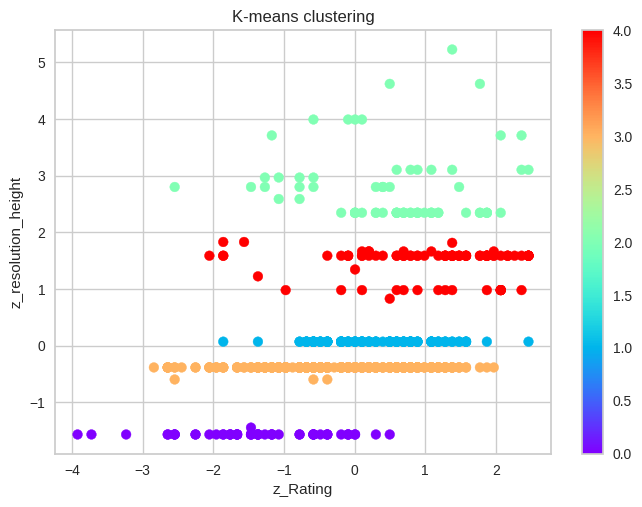

In [ ]:
k_means = KMeans(n_clusters = 5)
k_means = k_means.fit(X)
clusters = k_means.predict(X)
plt.scatter(df['z_Rating'], df['z_resolution_height'], c = clusters, cmap = 'rainbow')
plt.xlabel('z_Rating')
plt.ylabel('z_resolution_height')
plt.title('K-means clustering')
plt.colorbar()
plt.show()

### Cluster analysis


**Cluster 0:** Basic laptops

These are the devices with the lowest rating and screen resolution.

**Cluster 1:** Standard office notebooks

The laptops in this cluster have an average rating and screen resolution.

**Cluster 2:** Premium multimedia notebooks

Devices in this cluster have high ratings and very high screen resolutions.

**Cluster 3:** Laptops for creative and graphic work

These are high-resolution, high-rated devices probably designed for professionals working with graphics, photography or video.

**Cluster 4:** Gamer laptops

The laptops in this cluster have a high rating and screen resolution, they are probably gaming or professional devices that can handle high loads and modern games.

### Result validation

In [ ]:
f_val_rating, p_val_rating = stats.f_oneway(
    df[df['Clusters'] == 0]['z_Rating'],
    df[df['Clusters'] == 1]['z_Rating'],
    df[df['Clusters'] == 2]['z_Rating'],
    df[df['Clusters'] == 3]['z_Rating'],
    df[df['Clusters'] == 4]['z_Rating']
)

f_val_resolution_height, p_val_resolution_height = stats.f_oneway(
    df[df['Clusters'] == 0]['z_resolution_height'],
    df[df['Clusters'] == 1]['z_resolution_height'],
    df[df['Clusters'] == 2]['z_resolution_height'],
    df[df['Clusters'] == 3]['z_resolution_height'],
    df[df['Clusters'] == 4]['z_resolution_height']
)

print(f"ANOVA Results for z_Rating: F-value = {f_val_rating}, P-value = {p_val_rating}")
print(f"ANOVA Results for z_resolution_height: F-value = {f_val_resolution_height}, P-value = {p_val_resolution_height}")

ANOVA Results for z_Price: F-value = 70.87231684610302, P-value = 8.667364367360751e-53
ANOVA Results for z_display_size: F-value = 6667.073815501274, P-value = 0.0


Both results of ANOVA tests confirm that the clusters differ significantly in both price (z_Price) and screen size (z_display_size). These differences are statistically significant and therefore the results of the cluster analysis are valid.

## display_size and ram_memory

In [ ]:
df['z_display_size'] = (df['display_size'] - df['display_size'].mean())/df['display_size'].std()
df['z_ram_memory'] = (df['ram_memory'] - df['ram_memory'].mean())/df['ram_memory'].std()
df

,index,brand,Model,Price,Rating,processor_brand,processor_tier,num_cores,num_threads,ram_memory,...,display_size,resolution_width,resolution_height,OS,year_of_warranty,z_Price,z_display_size,Clusters,z_ram_memory,z_primary_storage_capacity
0,1,tecno,Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...,23990,63,intel,core i3,2,4,8,...,15.6,1920,1080,windows,1,-0.928406,0.457056,0,-0.902747,-0.370656
1,2,tecno,Tecno Megabook T1 Laptop (11th Gen Core i7/ 16...,35990,67,intel,core i7,4,8,16,...,15.6,1920,1080,windows,1,-0.719292,0.457056,2,0.528076,1.547466
2,3,hp,HP Victus 15-fb0157AX Gaming Laptop (AMD Ryzen...,51100,73,amd,ryzen 5,6,12,8,...,15.6,1920,1080,windows,1,-0.455982,0.457056,0,-0.902747,-0.370656
3,4,acer,Acer Extensa EX214-53 Laptop (12th Gen Core i5...,39990,62,intel,core i5,12,16,8,...,14.0,1920,1080,windows,1,-0.649587,-1.248540,0,-0.902747,-0.370656
4,5,lenovo,Lenovo V15 82KDA01BIH Laptop (AMD Ryzen 3 5300...,28580,62,amd,ryzen 3,4,8,8,...,15.6,1920,1080,windows,1,-0.848420,0.457056,0,-0.902747,-0.370656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
986,998,asus,Asus Vivobook Pro 15 M6500QC-HN542WS Laptop (R...,65990,68,amd,ryzen 5,6,12,16,...,15.6,1920,1080,windows,1,-0.196506,0.457056,1,0.528076,-0.370656
987,999,msi,MSI Thin GF63 12VE-070IN Gaming Laptop (12th G...,91990,73,intel,core i7,10,16,16,...,15.6,1920,1080,windows,2,0.256574,0.457056,1,0.528076,-0.370656
988,1000,asus,Asus Vivobook Go 15 2023 E1504FA-NJ522WS Lapto...,44990,59,amd,ryzen 5,4,8,8,...,15.6,1920,1080,windows,1,-0.562456,0.457056,0,-0.902747,-0.370656
989,1001,asus,Asus Zenbook 14 2023 UM3402YA-KP541WS Laptop (...,67990,68,amd,ryzen 5,6,12,16,...,14.0,2560,1600,windows,1,-0.161654,-1.248540,1,0.528076,-0.370656


In [ ]:
X = df[['z_display_size', 'z_ram_memory']]
X

,z_display_size,z_ram_memory
0,0.457056,-0.902747
1,0.457056,0.528076
2,0.457056,-0.902747
3,-1.248540,-0.902747
4,0.457056,-0.902747
...,...,...
986,0.457056,0.528076
987,0.457056,0.528076
988,0.457056,-0.902747
989,-1.248540,0.528076


In [ ]:
for k in range (2, 15):
    labels = KMeans(n_clusters=k).fit_predict(X)
    print('Number of clusters: {}, index {}'.format(k, calinski_harabasz_score(X, labels)))

Number of clusters: 2, index 311.49347670719084
Number of clusters: 3, index 879.7440568257824
Number of clusters: 4, index 1070.978341323187
Number of clusters: 5, index 2219.3534804262354
Number of clusters: 6, index 2149.066275768224
Number of clusters: 7, index 2358.3259489054003
Number of clusters: 8, index 3122.2691811075615
Number of clusters: 9, index 4415.882611489696
Number of clusters: 10, index 4450.042631895383
Number of clusters: 11, index 5692.154915542633
Number of clusters: 12, index 6365.785872936593
Number of clusters: 13, index 5988.485744001953
Number of clusters: 14, index 7228.669818213425


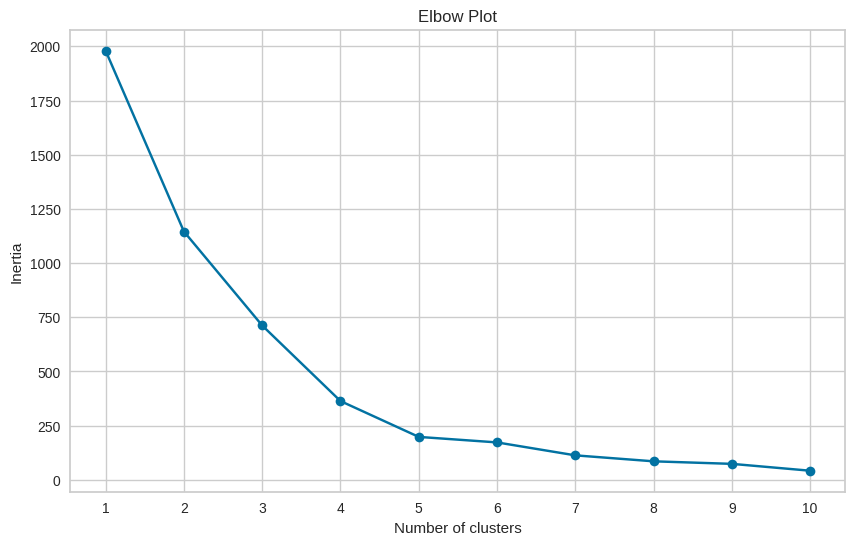

In [ ]:
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Plot')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.show()

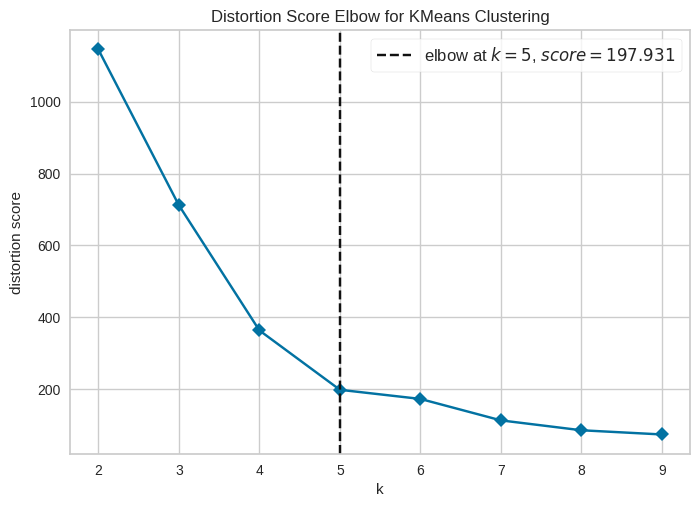

In [ ]:
from yellowbrick.cluster import KElbowVisualizer

model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2,10), timings=False)

visualizer.fit(X)
visualizer.show()
plt.show()

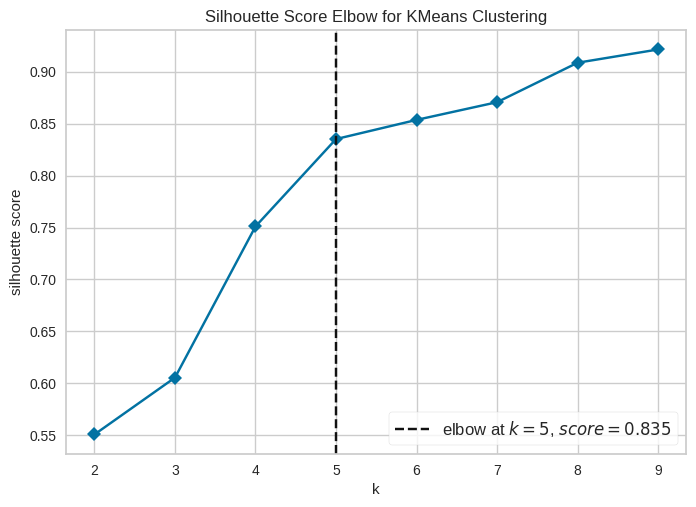

In [ ]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2,10), metric='silhouette', timings=False)

visualizer.fit(X)
visualizer.show()
plt.show()

In [ ]:
kmeans_model = KMeans(n_clusters=5).fit_predict(X)

In [ ]:
df['Clusters'] = kmeans_model
df.head()

,index,brand,Model,Price,Rating,processor_brand,processor_tier,num_cores,num_threads,ram_memory,...,display_size,resolution_width,resolution_height,OS,year_of_warranty,z_Price,z_display_size,Clusters,z_ram_memory,z_primary_storage_capacity
0,1,tecno,Tecno Megabook T1 Laptop (11th Gen Core i3/ 8G...,23990,63,intel,core i3,2,4,8,...,15.6,1920,1080,windows,1,-0.928406,0.457056,2,-0.902747,-0.370656
1,2,tecno,Tecno Megabook T1 Laptop (11th Gen Core i7/ 16...,35990,67,intel,core i7,4,8,16,...,15.6,1920,1080,windows,1,-0.719292,0.457056,0,0.528076,1.547466
2,3,hp,HP Victus 15-fb0157AX Gaming Laptop (AMD Ryzen...,51100,73,amd,ryzen 5,6,12,8,...,15.6,1920,1080,windows,1,-0.455982,0.457056,2,-0.902747,-0.370656
3,4,acer,Acer Extensa EX214-53 Laptop (12th Gen Core i5...,39990,62,intel,core i5,12,16,8,...,14.0,1920,1080,windows,1,-0.649587,-1.248540,3,-0.902747,-0.370656
4,5,lenovo,Lenovo V15 82KDA01BIH Laptop (AMD Ryzen 3 5300...,28580,62,amd,ryzen 3,4,8,8,...,15.6,1920,1080,windows,1,-0.848420,0.457056,2,-0.902747,-0.370656


In [ ]:
df['Clusters'].value_counts()

,count
Clusters,
0,366
2,298
1,157
3,132
4,38


In [ ]:
df.groupby('Clusters')[['z_display_size', 'z_ram_memory']].mean(numeric_only=True)

,z_display_size,z_ram_memory
Clusters,,
0,0.645498,0.528076
1,-1.359213,0.523519
2,0.503559,-0.921952
3,-1.455279,-0.992173
4,0.504745,3.427375


In [ ]:
df.groupby('Clusters')[['z_ram_memory', 'z_primary_storage_capacity']].describe()

z_ram_memory                                                        \
                count      mean           std       min       25%       50%   
Clusters                                                                      
0               366.0  0.528076  1.778789e-15  0.528076  0.528076  0.528076   
1               157.0  0.523519  5.709605e-02 -0.187335  0.528076  0.528076   
2               298.0 -0.921952  1.425105e-01 -1.618158 -0.902747 -0.902747   
3               132.0 -0.992173  2.435922e-01 -1.975864 -0.902747 -0.902747   
4                38.0  3.427375  1.618935e-01  3.389722  3.389722  3.389722   

                             z_primary_storage_capacity                      \
               75%       max                      count      mean       std   
Clusters                                                                      
0         0.528076  0.528076                      366.0  0.237273  0.926913   
1         0.528076  0.528076                      157.0  0.124146  0.852329   
2        -0.902747 -0.187335                      298.0 -0.354565  0.638868   
3        -0.902747 -0.902747                      132.0 -0.610422  0.800300   
4         3.389722  4.105133                       38.0  2.102712  1.472858   

                                                            
               min       25%       50%       75%       max  
Clusters                                                    
0        -0.370656 -0.370656 -0.370656  1.547466  5.383712  
1        -1.329718 -0.370656 -0.370656  1.547466  1.547466  
2        -2.049014 -0.370656 -0.370656 -0.370656  5.383712  
3        -2.168896 -1.329718 -0.370656 -0.370656  1.547466  
4        -0.370656  1.547466  1.547466  1.547466  5.383712

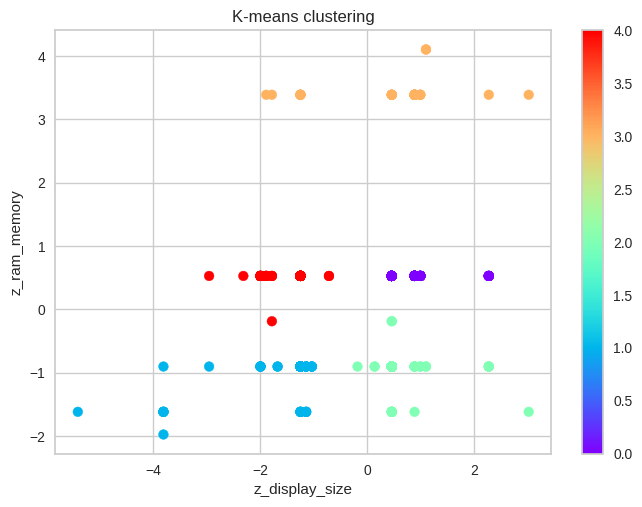

In [ ]:
k_means = KMeans(n_clusters = 5)
k_means = k_means.fit(X)
clusters = k_means.predict(X)
plt.scatter(df['z_display_size'], df['z_ram_memory'], c = clusters, cmap = 'rainbow')
plt.xlabel('z_display_size')
plt.ylabel('z_ram_memory')
plt.title('K-means clustering')
plt.colorbar()
plt.show()

### Cluster analysis


**Cluster 0:** Balanced laptops

Laptops in this cluster have a medium screen size and a moderate amount of RAM.

**Cluster 1:** Compact but Powerful Laptops

Despite the small screen, the devices in this cluster have a fair amount of RAM.

**Cluster 2:** Laptops with low memory capacity

These laptops have a relatively average screen size, but not enough RAM.

**Cluster 3:** Compact budget laptops

Devices with a small screen and low RAM.

**Cluster 4:** Powerful multimedia notebooks
Laptops with large screens and very high RAM.

### Result validation

In [ ]:
f_val_display_size, p_val_display_size = stats.f_oneway(
    df[df['Clusters'] == 0]['z_display_size'],
    df[df['Clusters'] == 1]['z_display_size'],
    df[df['Clusters'] == 2]['z_display_size'],
    df[df['Clusters'] == 3]['z_display_size'],
    df[df['Clusters'] == 4]['z_display_size']
)

f_val_ram_memory, p_val_ram_memory = stats.f_oneway(
    df[df['Clusters'] == 0]['z_ram_memory'],
    df[df['Clusters'] == 1]['z_ram_memory'],
    df[df['Clusters'] == 2]['z_ram_memory'],
    df[df['Clusters'] == 3]['z_ram_memory'],
    df[df['Clusters'] == 4]['z_ram_memory']
)

print(f"ANOVA Results for z_display_size: F-value = {f_val_display_size}, P-value = {p_val_display_size}")
print(f"ANOVA Results for z_ram_memory: F-value = {f_val_ram_memory}, P-value = {p_val_ram_memory}")

ANOVA Results for z_display_size: F-value = 23.964395599707924, P-value = 6.103746101125209e-19
ANOVA Results for z_ram_memory: F-value = 62.31838587120199, P-value = 5.548743136488738e-47


Both tests show that clusters differ significantly in both screen size (z_display_size) and RAM (z_ram_memory). These differences are statistically significant, which confirms the validity of the cluster analysis on these variables.

<font color='red'>To perform ANOVA test, you also had the assumption of the test (normality of distribution of the variables).

Detailed description of the obtained clusters is missing. Also, you computed many various metrics, but did not discuss them, so the reasonyou needed to compute them was not clear.</font>